## Lab 1 Introduction to Python

In ELEC3705 lab, we will mainly focus on linear-algebra-based computation. To do so, we need to import the NumPy library, which allows you to define data types as multi-dimensional arrays and matrices. NumPy also provides a large collection of mathematical functions to operate on these objects. If you have never used python before, don't be intimidated, we will go through all the basics!
<br><br>

We will be using Jupyter notebooks throughout this course, where you can make markdowns, comment in scientific notation, and run the program cell by cell. Below is a basic introduction to Python basics that we will run through during the first lab.

### 1. Import libraries for fast vector-based compuatation
NumPy and SciPy packages should be already installed when you install Anaconda. There is no need to download them again
<br>
Any other packages you want to import can also be included here at the beginning of the document or you can import them as and when you need them.

In [1]:
import numpy as np # imports all functions and classes from the numpy library, we'll use the prefix np to access them
import scipy as sp
from numpy import linalg as LA # linalg is a subpackage of numpy
from scipy.linalg import logm, expm # linalg is a subpcackage of scipy, if we import the functions we don't neet to call them with the prefix sp.linalg

### 2. List, Vectors and Matrixes 

The python default method of storing an array of numbers is the list []. The advantage of a list is that you can add anything to a list. You could add a dictionary ({'a': 1}), floating point (1.1), integer 1 and even more lists ([]) in the same list.

In [2]:
list1 = [1, 2, 3]
list1

[1, 2, 3]

In [3]:
len(list1)

3

In [4]:
list2 = [{'a': 1}, 1.1,  1, [1, 2]]
list2

[{'a': 1}, 1.1, 1, [1, 2]]

However lists don't beheave like vectors. This makes them not the ideal object to do linear algebra and thus quantum physics with.

See for instance what happens if we multiply a list with a number:

In [5]:
v_list = [1,2]
v_list*2

[1, 2, 1, 2]

Instead we will use the 'array' object from the numpy (imported as np) module. The function np.array() takes a list as input and turns it into a numpy array. The numpy array is much more suited to use for numerics.

In [6]:
v_array = np.array([1,2])
v_array*2

array([2, 4])

Unlike lists, the elements of a numpy array should all be of the same data type. When making a numpy array the data type is set based on your initial inputs. Often times you will start of with integers only. Numpy arrays are pretty smart and will switch data type if necessary, but you need to watch out with complex numbers! 

In [7]:
np.array([1, 0]).dtype

dtype('int64')

In [8]:
np.array([1.1, 0]).dtype

dtype('float64')

In [9]:
np.array([1j, 0]).dtype

dtype('complex128')

### 2.2 Vectors and shape

The arrays we have seen so far don't have a vector like 'shape' yet. There is no difference between a row or column vector and thus also not between a 'bra' and 'ket'. We can add dimensions to a np.array by putting lists inside of lists.

In [10]:
x0 = np.array([1, 0])
x0.shape # only a single dimension is defined

(2,)

In [11]:
x1 = np.array([[1, 0]])
print('shape of x1:', x1.shape) # now it has two dimensions, but the second dimension has size 1
x1

shape of x1: (1, 2)


array([[1, 0]])

In [12]:
x2 = np.array([[1], [0]])
print('shape of x2:', x2.shape) # the dimensions are swapped compared to x1
x2

shape of x2: (2, 1)


array([[1],
       [0]])

And now we also know how to make a matrix

In [13]:
m1 = np.array([[1, 0], [0, 1]])
print('shape of m1:', m1.shape)
m1

shape of m1: (2, 2)


array([[1, 0],
       [0, 1]])

#### <font color='green'>Task</font> : Intialise $| \downarrow \rangle $ and $| \uparrow \rangle $ and using np.array. Calculate the corresponding bras $\langle \downarrow |$ and $\langle \uparrow |$ 

(check the lecture slides if you don't know what vectors you need)

In [15]:
# Answer
d_ket = np.array([[0],[1]])
u_ket = np.array([[1],[0]])
d_bra = d_ket.T
u_bra = u_ket.T






####  <font color='green'>Task</font>: Intialise the +x (+) state using np.array

$|+\rangle = (| \uparrow \rangle + | \downarrow \rangle)/\sqrt(2)$  

In [16]:
# Answer
xp = (u_ket+d_ket)/np.sqrt(2)
print(xp)






[[0.70710678]
 [0.70710678]]


Two usefull built in functions for regulating the shape of an array are np.transpose (.T) and np.reshape (.reshape()) 

In [17]:
bra = np.array([[1, 0]]) # row vector
ket = np.transpose(bra) # column vector
ket

array([[1],
       [0]])

In [18]:
bra.T

array([[1],
       [0]])

In [ ]:
array = np.array([0, 1, 2, 3, 4, 5])
matrix = array.reshape((2, 3)) # reshape to a 2x3 matrix
matrix

####  <font color='green'>Task</font>: Turn the 'shapeless' array test_array into a column vector (with shape (2, 1)).

In [19]:
test_array = np.array([1, 1])
print(test_array.shape)

# answer 
array = test_array.reshape((2,1))
array

(2,)


array([[1],
       [1]])

### 2.3 storing vectors and indexing arrays

In [ ]:
memory = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
memory[0]

In [ ]:
memory[3]

In [ ]:
memory[0:4] # slicing, note that the last index is not included

In [ ]:
memory[-1]

In [ ]:
memory_2d = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]])
print(memory_2d.shape)
memory_2d[0, 0] # first row, first column

In [ ]:
memory_2d[0, :] 

In [ ]:
memory_2d[:, 0] 

We can store values in an existing array by overwriting them

In [ ]:
memory[3] = 10
memory

In [ ]:
memory_2d[:, 0] = np.array([-1, -2, -3, -4])
memory_2d

We can store vectors (for instance quantum states) as a bunch of individual arrays in a list

In [ ]:
up = np.array([[1], [0]])
down = np.array([[0], [1]])
state_list = [up, down, up, down]

In [ ]:
state_list[3]

In [ ]:
state_list.append(np.array([[1], [1]])) # a usefull function for adding things to a list
state_list

You might want to store the states more ellegantly using a single numpy array

In [ ]:
np.array([[1, 0, 1, 0, 1], [0, 1, 0, 1, 0]])

### There is a common problem with assigning kets to a numpy array! When you ask for a column of a numpy array it will 'loose its shape'. If you then want to overwrite this column with a ket (a column vector) it will complain about the shapes not matching!

In [ ]:
memory2 = np.array([[0, 0, 0, 0], [0, 0, 0, 0]])
memory2

In [ ]:
memory2[:, 3] # length 2 so it is clearly a column of the previous array

In [ ]:
memory2[:, 3].shape # shape is (2,) so it has lost its second dimension

In [ ]:
memory2[:, 3] = up # pultting a ket in the array will now not fit

In [ ]:
memory2[:, 3] = up.T # putting a bra instead would work

In [ ]:
memory2[:, 3] = up.reshape(2) # or reshaping

####  <font color='green'>Task</font>: Fill up the ket_memory array with all $|\uparrow \rangle$ kets and bra_memory with all $\langle \uparrow |$ bras

In [31]:
ket_memory = np.array([[0, 0, 0, 0], [0, 0, 0, 0]])
bra_memory = np.array([[0, 0], [0, 0], [0, 0], [0, 0]])

# answer
for i in range(4):
    ket_memory[:, i] = u_ket.T

for i in range (4):
    bra_memory[i, :] = d_ket.T

print(ket_memory)
print(bra_memory)

[[1 1 1 1]
 [0 0 0 0]]
[[0 1]
 [0 1]
 [0 1]
 [0 1]]


### 2.4. Matrix and the matrix product

####  <font color='green'>Task</font>: Initialize Pauli matrices $\sigma_x$, $\sigma_y$ and $\sigma_z$

(See slides if necessary)

In [34]:
# Answer
pauli_x = np.array([[0, 1],[1,0]])
pauli_y = np.array([[0, -1j],[1j, 0]])
pauli_z = np.array([[1, 0], [0, -1]])

print(pauli_x)
print(pauli_y)
print(pauli_z)


[[0 1]
 [1 0]]
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
[[ 1  0]
 [ 0 -1]]


The normal product * between np.arrays is ment for so called vectorisation of a calculation that would otherwise require some kind of loop.
This can be usefull in other cases but it is not what we need for our linear algebra.

In [ ]:
# It's not Matrix vector multiplication!
m = np.array([[2,0],[0,2]])
v = np.array([[1],[0]])

m*v

In stead to do a proper matrix product (or matrix vector product) we use the @

In [ ]:
m@v

####  <font color='green'>Task</font>: Create the matrix $U = \begin{pmatrix} \epsilon & \Delta \\ \Delta & -\epsilon \end{pmatrix}$, where $\epsilon = 1$, and $\Delta = 0.1$. Apply the matrix to the $|\uparrow \rangle$ state.  

In [47]:
# answer 
epsilon = 1
delta = 0.1

U = np.array([[epsilon, delta], [delta, -epsilon]])
U = delta * pauli_x + epsilon * pauli_z

U@u_ket


array([[1. ],
       [0.1]])

####  <font color='green'>Task</font>: Calculate the overlap of the down state and the up state, which is given by the following product: $\langle \downarrow | \uparrow \rangle $

In [36]:
# answer 

d_bra@u_ket

array([[0]])

### 2.5. Some built-in functions to intialise vectors and matrices

In [ ]:
# Identity Matrix
identity_matrix = np.identity(2)
identity_matrix

In [ ]:
# Value starts from 0 in python
np.arange(10)

In [ ]:
np.arange(2,10,2)

In [ ]:
v1 = np.arange(10,1,-1) # left included, right exculded
v1

In [ ]:
v2 = np.linspace(1,10,20) # left included, right exculded
print('len(v2):', len(v2))
v2


In [ ]:
np.zeros((2,3))

In [ ]:
np.ones((2,3)) #2*3 2-d array(matrix)


Another build in function we will be using a lot is the matrix exponential which comes from scipy. It should already be imported so you can just call it.

In [ ]:
mat = np.array([[0, 1], 
                [2, 0]])

In [ ]:
expm(mat) # since we imported the function explicityly we don't need to do scipy.linalg.expm

In [ ]:
np.exp(mat)

####  <font color='green'>Task</font>: What is the difference between scipy's 'expm' function and np.exp?

The expm function is the exponential matrix, which is calculated using Taylor series, whereas the np.exp function is the natural exponent of elements.

## 3. Eigenvectors and Eigenvalues

Eigenvalues and eigen vectors will be important later on. It is good to know how to calculate them by hand but luckily we can also ask numpy to give them for us.

In [39]:
sigma_z = np.array([[1,0],[0,-1]]) 
sigma_x = np.array([[0,1],[1,0]]) 
sigma_y = np.array([[0,-1j], [1j, 0]]) 

vals, vecs = LA.eig(sigma_x) #remember LA is how we called the submodule np.linalg

print("Eigenvalues are: \n", vals)
print("Eigenvectors are: \n", vecs)
print(vecs[:,1]) # Note eigenvectors are in column vector

Eigenvalues are: 
 [ 1.+0.j -1.+0.j]
Eigenvectors are: 
 [[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]
[-0.70710678+0.j  0.70710678+0.j]


####  <font color='green'>Task</font>: Compare the eigenvalues of the three pauli matrices (sigma_x, sigma_y and sigma_z)

In [41]:
# answer
x_val, x_vec = LA.eig(sigma_x)
y_val, y_vec = LA.eig(sigma_y)
z_val, z_vec = LA.eig(sigma_z)

print(f"x: {x_val}, y: {y_val}, z: {z_val}")
print(x_vec, y_vec, z_vec)

x: [ 1.+0.j -1.+0.j], y: [ 1.+0.j -1.+0.j], z: [ 1.+0.j -1.+0.j]
[[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]] [[-0.        -0.70710678j  0.70710678+0.j        ]
 [ 0.70710678+0.j          0.        -0.70710678j]] [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


## 4. For loop

Loops automate repetitive code. In this course we will only need the 'for' loop which is demonstrated in this section.

In [ ]:
for i in range(10):
    print(i)

In [42]:
numbers = np.linspace(1,10,10)
for number in numbers:
    print(number)

1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0


####  <font color='green'>Task</font>: Loop over all numbers and print both the index and the number ('index' : 'number')

In [43]:
# answer

for i, number in enumerate(numbers):
    print(f"{i}: {number}")

0: 1.0
1: 2.0
2: 3.0
3: 4.0
4: 5.0
5: 6.0
6: 7.0
7: 8.0
8: 9.0
9: 10.0


### 5. Tensor product (optional)

Tensor products are uses when you have more than one quantum system. They will be introduced later on but you can allready see the numpy functions for it

In [ ]:
S_xI = np.kron(sigma_x,np.identity(2))
S_xI

In [ ]:
uu = np.kron(up,up)
uu

In [ ]:
rho = uu * uu.T
rho

In [ ]:
def par_trace_A(rho):
    par_A = np.array([[(rho[0,0]+rho[1,1]),(rho[0,2]+rho[1,3])],[(rho[2,0]+rho[3,1]),(rho[2,2]+rho[3,3])]])
    return par_A
def par_trace_B(rho):
    par_B = np.array([[(rho[0,0]+rho[2,2]),(rho[0,1]+rho[2,3])],[(rho[1,0]+rho[3,2]),(rho[1,1]+rho[3,3])]])
    return par_B

In [ ]:
parA = par_trace_A(rho)
parA

## 6. Plotting

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interactive

#### 6.1 Matplotlib.pyplot

In [ ]:
# This is easiest way to plot a figure, but not able to zoom in and measure
t = np.linspace(-2,8,100)
f = 1000
y0 = np.sin(2*np.pi*f*t)
y = y0 + np.random.rand(len(t))
plt.plot(t,y)
plt.xlabel('time(s)')
plt.ylabel('Arb. Axis')
plt.title('plot a noisy sine')
plt.show()

####  <font color='green'>Task</font>: Plot in a single figure a sine wave with f=1000, f=2000 and f=3000.

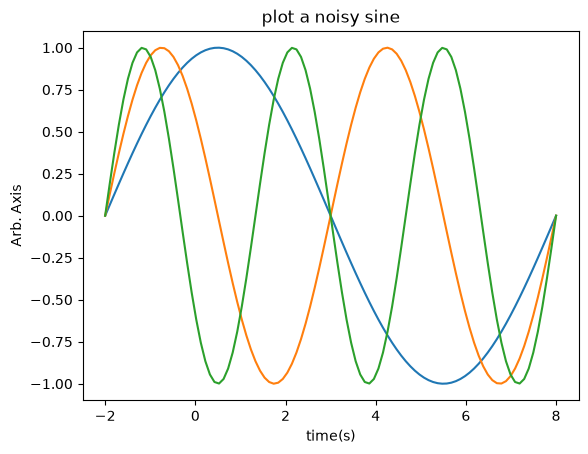

In [46]:
import matplotlib.pyplot as plt
t = np.linspace(-2, 8, 100)
y1000 = np.sin(2*np.pi*1000*t)
y2000 = np.sin(2*np.pi*2000*t)
y3000 = np.sin(2*np.pi*3000*t)
plt.plot(t,y1000)
plt.plot(t,y2000)
plt.plot(t,y3000)
plt.xlabel('time(s)')
plt.ylabel('Arb. Axis')
plt.title('plot a noisy sine')
plt.show()

#### 6.3 Interactive Plot (Optional)

In [ ]:
# define a function that takes in A and B,x, and output a plot
def plotter(A,B):
    y = A*np.sin(B*x)
    plt.plot(x,y)
    plt.grid()
    plt.ylim(-10,10)
    plt.show()

In [ ]:
x = np.linspace(0,2*np.pi,100)
# define the interactive plotting tool.
iplot = interactive(plotter, A=  (-3,10,0.1),B=(1,5,0.5))
iplot